In [ ]:
import torch
import os
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
from math import floor
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchmetrics.classification import BinaryAccuracy, BinaryRecall, BinaryPrecision, BinaryF1Score, BinaryAUROC, BinaryAveragePrecision, BinarySpecificity
from torchvision import transforms
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
import time
from torch import nn

## GETTING DATA
path_to_cancerous_data = r"..."

meta = []
img = []

for i in os.listdir(path_to_cancerous_data):
    p = os.path.join(path_to_cancerous_data,i)
    if i == "ham10000":
        meta.append(pd.read_csv(os.path.join(p,"HAM10000_metadata.csv")))
        img.extend(p + "\\" + "HAM10000_images_part_1" + "\\" + i for i in os.listdir(os.path.join(p,"HAM10000_images_part_1")))
        img.extend(p + "\\" + "HAM10000_images_part_2" + "\\" + i for i in os.listdir(os.path.join(p,"HAM10000_images_part_2")))

    if i == "ISIC2020":
        meta.append(pd.read_csv(os.path.join(p,"PatientMetaData.csv")))
        img.extend(p + "\\" + "ISIC_2020_Training_JPEG" + "\\" + i for i in os.listdir(os.path.join(p,"ISIC_2020_Training_JPEG")))

    if i == "KaggleData":
        img.extend(p + "\\" + "benign" + "\\" + i for i in os.listdir(os.path.join(p,"benign")))
        meta.extend(np.zeros(len(os.listdir(os.path.join(p,"benign")))))
        img.extend(p + "\\" + "malignant" + "\\" + i for i in os.listdir(os.path.join(p,"malignant")))
        meta.extend(np.ones(len(os.listdir(os.path.join(p,"malignant")))))

path_to_cancerous_data = r"..."


for i in range(len(os.listdir(path_to_cancerous_data))):
    if i != 1:
        i = os.listdir(path_to_cancerous_data)[i]
        p = os.path.join(path_to_cancerous_data,i)
        idx = 0
        if os.listdir(p)[0].endswith(".csv"):
            idx = 1
        img_p = os.path.join(p,os.listdir(p)[idx])
        img_p = os.path.join(img_p,os.listdir(img_p)[0])
        img.extend(img_p + "//" + i for i in os.listdir(img_p) if not i.endswith(".txt"))
        meta.append(pd.read_csv(os.path.join(p,os.path.join(p,os.listdir(p)[1 - idx]))))
    
    else:
        i = os.listdir(path_to_cancerous_data)[i]
        p = os.path.join(path_to_cancerous_data,i)
        idx = 0
        if os.listdir(p)[0].endswith(".csv"):
            idx = 1
        img_p = os.path.join(p,os.listdir(p)[idx])
        img_p = os.path.join(img_p,os.listdir(img_p)[0])
        
        iter_list = [img_p + "//" + i for i in os.listdir(img_p) if not i.endswith(".txt")]

        img.extend(np.array(iter_list)[::2])
        meta.append(pd.read_csv(os.path.join(p,os.path.join(p,os.listdir(p)[1 - idx]))))



img = np.array(img)

## for predicting cancerous moles

targets = meta.copy()

benign = ["nv", "bkl", "df", "vasc"]

targets[0] = (1 - targets[0].dx.isin(benign).astype(int)).values
targets[1] = targets[1].target.values

#targets = #np.concatenate([targets[0], targets[1],targets[2:-4],1 - np.array(targets[-4].benign == "benign").astype(int), targets[-3]["melanoma"].values, targets[-2]["MEL"].values,targets[-1]["MEL"].values])
targets = np.concatenate([targets[0], targets[1],targets[2:-4], (targets[-4].benign == "malignant").astype(int).values, (targets[-3].melanoma).astype(int).values, targets[-2]["MEL"].values,targets[-1]["MEL"].values])


targets = list(targets)
img = list(img)

## Gets New ISIC 2024 data

## Gets New ISIC 2024 data

path_to_cancerous_data = r"..."

idx = 0
if os.listdir(path_to_cancerous_data)[idx].endswith(".csv"):
    idx = 1

targets.extend(pd.read_csv(os.path.join(path_to_cancerous_data,os.listdir(path_to_cancerous_data)[1 - idx])).malignant.astype(int).values)
img.extend([os.path.join(path_to_cancerous_data, os.path.join(os.listdir(path_to_cancerous_data)[idx], i)) for i in os.listdir(os.path.join(path_to_cancerous_data,os.listdir(path_to_cancerous_data)[idx])) if not (i.endswith(".txt") or i.endswith(".csv"))]) ## Metadata stored as the last files here



## FINISHED DATA

## Now we Select Data

torch.manual_seed(2009)

img = np.array(img)
targets = np.array(targets)

idx = torch.randperm(len(img))

X_tr = img[idx[:int(0.8*len(idx))]]
X_ts = img[idx[int(0.8*len(idx)):]]

y_tr = targets[idx[:int(0.8*len(idx))]]
y_ts = targets[idx[int(0.8*len(idx)):]]


tr_transforms = transforms.Compose([
        transforms.RandomResizedCrop((256,384), scale = (0.6,0.8)),
        transforms.RandomHorizontalFlip(p = 0.5),
        transforms.RandomRotation(30),
        transforms.RandomPerspective(distortion_scale= 0.75, p = 0.5),
        transforms.ElasticTransform(alpha = 20.0, sigma= 10.0),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.05, hue=0.05),
        transforms.ToTensor()
    ])


## MODEL & Loaders Setup

class MoleDataset(Dataset):
    def __init__(self, X, y, transform):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.y)
    
    def __getitem__(self,idx):
        return self.transform(Image.open(self.X[idx])), torch.from_numpy(np.array([self.y[idx]])).float()

In [6]:
model = timm.create_model(
        "efficientnet_b3",
        pretrained=True,
        num_classes = 1
    )

config = resolve_data_config({}, model=model)
transform = create_transform(**config)

prev_t = transform.transforms[:2]
prev_t.extend(tr_transforms.transforms[1:-1])
prev_t.extend(transform.transforms[2:])

tr_transforms = transforms.Compose(prev_t)
ts_transforms = transform

tr_dataset = MoleDataset(X_tr, y_tr, tr_transforms)
ts_dataset = MoleDataset(X_ts, y_ts, ts_transforms)

In [7]:
model.classifier = nn.Sequential(
        nn.Linear(1536,512),
        nn.LeakyReLU(0.05),
        nn.Dropout(p=0.3),
        nn.Linear(512,128),
        nn.LeakyReLU(0.05),
        nn.Linear(128,1)
        )
model = model.to("cuda")
loaded_stage = 5
model.load_state_dict(torch.load(f"stage{loaded_stage}_best.pt"))

<All keys matched successfully>

In [13]:
import os 
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [14]:
ts_loader = DataLoader(ts_dataset,batch_size=32)

In [51]:
X, y= next(iter(ts_loader))


In [ ]:
X_ts[:5] = X_ts[torch.nonzero(torch.from_numpy(y_ts) == 1)[:5]].reshape(-1)

In [57]:
y_ts[:5] = 1

In [60]:
X_ts = X_ts[:32]
y_ts = y_ts[:32]

In [62]:
p = torch.randperm(len(X_ts))

X_ts = X_ts[p]
y_ts = y_ts[p]

In [66]:
transforms.ToTensor()(Image.open(X_ts[0]))

tensor([[[0.7333, 0.7176, 0.7020,  ..., 0.7843, 0.7765, 0.7686],
         [0.7176, 0.7098, 0.7098,  ..., 0.7961, 0.7882, 0.7725],
         [0.7059, 0.7059, 0.7176,  ..., 0.8118, 0.8000, 0.7843],
         ...,
         [0.7020, 0.7020, 0.7137,  ..., 0.8000, 0.8000, 0.8000],
         [0.7216, 0.7216, 0.7255,  ..., 0.7961, 0.7961, 0.7961],
         [0.7529, 0.7490, 0.7412,  ..., 0.7922, 0.7922, 0.7922]],

        [[0.5373, 0.5216, 0.5059,  ..., 0.6078, 0.6000, 0.5922],
         [0.5216, 0.5137, 0.5137,  ..., 0.6196, 0.6118, 0.5961],
         [0.5098, 0.5098, 0.5216,  ..., 0.6353, 0.6235, 0.6078],
         ...,
         [0.5137, 0.5137, 0.5255,  ..., 0.6235, 0.6235, 0.6235],
         [0.5333, 0.5333, 0.5373,  ..., 0.6196, 0.6196, 0.6196],
         [0.5647, 0.5608, 0.5529,  ..., 0.6157, 0.6157, 0.6157]],

        [[0.4471, 0.4314, 0.4157,  ..., 0.5176, 0.5098, 0.5020],
         [0.4314, 0.4235, 0.4235,  ..., 0.5294, 0.5216, 0.5059],
         [0.4196, 0.4196, 0.4314,  ..., 0.5451, 0.5333, 0.

In [18]:
from math import floor

In [71]:
res

0

In [87]:
int((torch.sigmoid(model((tens).unsqueeze(0).to("cuda"))) > 0.2).item())

1

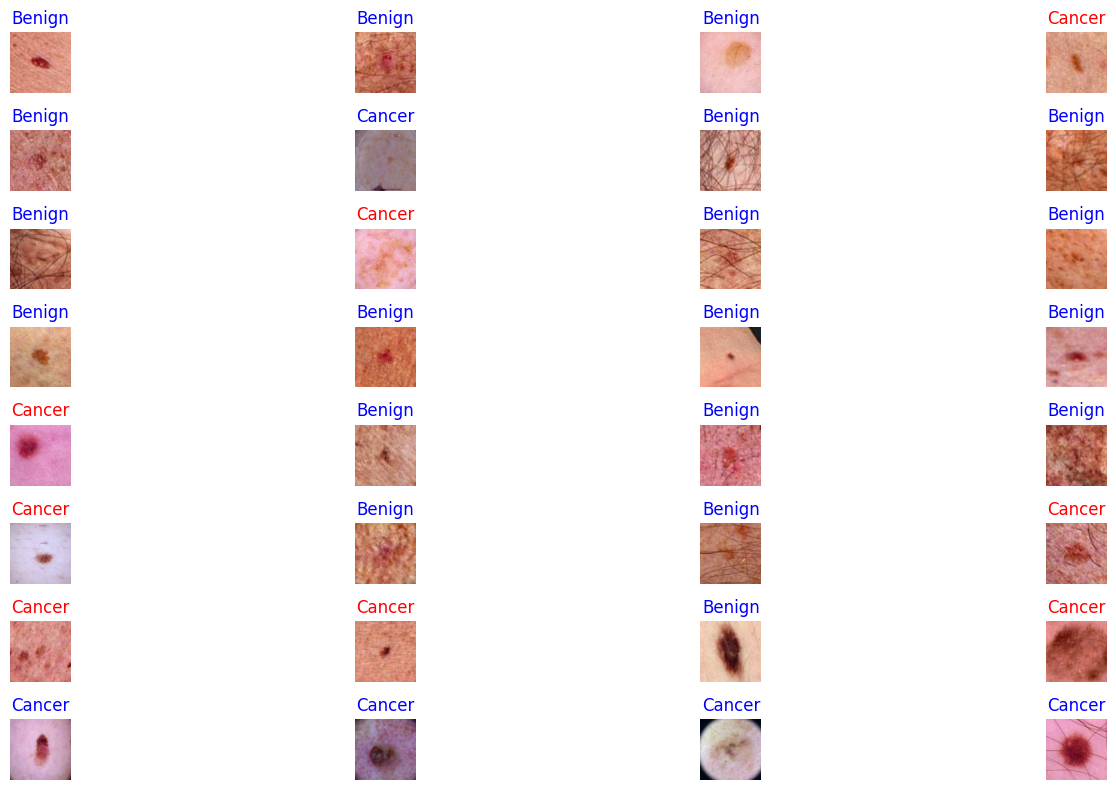

In [95]:
fig, axes = plt.subplots(8,4, figsize = (16,8))
for i in range(len(X)):
    tens = ts_transforms(Image.open(X_ts[i]))
    model.eval()
    res = int((torch.sigmoid(model((tens).unsqueeze(0).to("cuda"))) > 0.33).item())
    tens = tens.permute([1,2,0]).numpy()
    tens = (tens - tens.min()) / (tens.max() - tens.min())
    axes[floor(i / 4)][i % 4].imshow(tens)
    axes[floor(i / 4)][i % 4].axis("off")

    axes[floor(i / 4)][i % 4].set_title({0 : "Benign", 1 : "Cancer"}[res], color= {False : "red", True : "blue"}[res == y_ts[i]])

fig.tight_layout()

In [77]:
tens = ts_transforms(Image.open(X_ts[i]))

In [78]:
model((tens).unsqueeze(0).to("cuda"))

tensor([[-0.4418]], device='cuda:0', grad_fn=<AddmmBackward0>)